# CIFAR-10: 2D graph/similarity-based μειωση διαστασης + spectral clustering

Σε αυτο το notebook:

1. Φορτωνω CIFAR-10 και παιρνω stratified subset (ισος αριθμος δειγματων ανα κλαση) για να ειναι εφικτες οι μεθοδοι manifold/graph.
2. Δουλευω σε **raw pixels** (χωρις HOG).
3. Κανω scaling στα features (StandardScaler) για να εχουν νοημα οι αποστασεις/γειτονιες.
4. Υπολογιζω 2D embedding με μεθοδους που βασιζονται:
   - σε φασματικη αναλυση γραφου (SpectralEmbedding)
   - σε ομοιοτητες/γειτονιες (LPP, LLE, Isomap, t-SNE, KernelPCA)
5. Παιρνω τα 2D δεδομενα και εφαρμοζω **Spectral Clustering**.
6. Οπτικοποιω τις ομαδες με διαφορετικα χρωματα.
7. Κανω εξερευνηση (grid) σε συνδιασμους μεθοδων και παραμετρων και κραταω metrics (ARI/NMI) για συγκριση.


Load libraries

In [1]:
from data_loader import load_cifar10
import matplotlib.pyplot as plt
import numpy as np
import time

from sklearn.preprocessing import StandardScaler

# 2D embeddings (graph/similarity based)
from sklearn.manifold import SpectralEmbedding, Isomap, LocallyLinearEmbedding, TSNE
from sklearn.decomposition import KernelPCA

# spectral clustering
from sklearn.cluster import SpectralClustering

from sklearn.neighbors import NearestNeighbors
import scipy.sparse as sp
from scipy.linalg import eigh
from lpproj import LocalityPreservingProjection

# optional evaluation (unsupervised agreement with true labels)
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


## Load CIFAR-10

Φορτωνω το CIFAR-10 και κραταω train/test και label_names.


In [2]:
data = load_cifar10("cifar-10-batches-py")
X_train, y_train = data["x_train"], data["y_train"]
X_test, y_test   = data["x_test"], data["y_test"]
label_names = data["label_names"]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)
print("Num classes:", len(label_names), label_names)


X_train: (50000, 32, 32, 3) y_train: (50000,)
X_test : (10000, 32, 32, 3) y_test : (10000,)
Num classes: 10 ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Stratified subset (ισος αριθμος ανα κλαση)

Επειδη οι graph/manifold μεθοδοι δεν ειναι πρακτικες στο πληρες CIFAR-10, παιρνω stratified subset.
Ετσι μπορω να συγκρινω δικαια τις μεθοδους σε ιδια δεδομενα.


In [3]:
def select_stratified_subset(
    X_train_flat, y_train,
    X_test_flat, y_test,
    n_train_per_class, n_test_per_class,
    random_state=0):
    
    num_classes = len(label_names)

    rng = np.random.default_rng(random_state)
    train_indices = []

    for c in range(num_classes):
        class_idxs = np.where(y_train == c)[0]
        if len(class_idxs) < n_train_per_class:
            raise ValueError(
                f"Not enough train samples for class {c}: "
                f"have {len(class_idxs)}, requested {n_train_per_class}"
            )
        chosen = rng.choice(class_idxs, size=n_train_per_class, replace=False)
        train_indices.append(chosen)

    train_indices = np.concatenate(train_indices)
    rng.shuffle(train_indices)

    X_train_sub = X_train_flat[train_indices]
    y_train_sub = y_train[train_indices]

    test_indices = []
    
    for c in range(num_classes):
        class_idxs = np.where(y_test == c)[0]
        if len(class_idxs) < n_test_per_class:
            raise ValueError(
                f"Not enough test samples for class {c}: "
                f"have {len(class_idxs)}, requested {n_test_per_class}"
            )
        chosen = rng.choice(class_idxs, size=n_test_per_class, replace=False)
        test_indices.append(chosen)

    test_indices = np.concatenate(test_indices)
    rng.shuffle(test_indices)

    X_test_sub = X_test_flat[test_indices]
    y_test_sub = y_test[test_indices]

    print("Train shape:", X_train_sub.shape, "Test shape:", X_test_sub.shape)
    return X_train_sub, y_train_sub, X_test_sub, y_test_sub

In [4]:
# experimenting με το μεγεθος
N_TRAIN_PER_CLASS = 200  # 200*10 = 2000
N_TEST_PER_CLASS  = 50

X_train_sub, y_train_sub, X_test_sub, y_test_sub = select_stratified_subset(
    X_train, y_train,
    X_test,  y_test,
    n_train_per_class=N_TRAIN_PER_CLASS,
    n_test_per_class=N_TEST_PER_CLASS,
    random_state=0
)


Train shape: (2000, 32, 32, 3) Test shape: (500, 32, 32, 3)


## Raw pixels -> vector + scaling

Επειδη δεν χρησιμοποιω HOG αυτη τη φορα, δουλευω σε raw pixels.
Κανω flatten καθε εικονα (32x32x3 -> 3072 features) και μετα StandardScaler ωστε οι αποστασεις/γειτονιες να ειναι πιο σταθερες.


In [5]:
# flatten raw pixels
X_flat = X_train_sub.reshape(X_train_sub.shape[0], -1).astype(np.float32)
print("Flat shape:", X_flat.shape)

# scaling
scaler = StandardScaler()
X_flat_s = scaler.fit_transform(X_flat)
print("Scaled flat shape:", X_flat_s.shape)


Flat shape: (2000, 3072)
Scaled flat shape: (2000, 3072)


## 2D Embeddings (graph/similarity-based)

Οριζω μια ενιαια συναρτηση που επιστρεφει 2D embedding για διαφορετικες μεθοδους:

- **spectral_embedding**: φασματικη αναλυση γραφου (Laplacian eigenmaps)
- **lpp (Locality Preserving Projections)**: γραμμικο graph embedding που διατηρει τοπικες γειτονιες (learned projection απο υψηλη διασταση σε 2D)
- **isomap**: geodesic αποστασεις σε kNN graph
- **lle**: τοπικη γραμμικη ανακατασκευη απο γειτονες
- **tsne**: similarity-based πιθανοτητες γειτονιας + optimization
- **kpca_rbf / kpca_poly**: kernel PCA (similarity via kernel)

Μετα το embedding, ομαδοποιω με spectral clustering στον 2D χωρο.


umap . hbd scan clustering?

In [11]:
def compute_embedding_2d(method, X, random_state=0, n_neighbors=15, tsne_perplexity=30):
    method = method.lower()

    if method == "spectral_embedding":
        model = SpectralEmbedding(
            n_components=2,
            affinity="nearest_neighbors",
            n_neighbors=n_neighbors,
            random_state=random_state
        )

    elif method == "isomap":
        model = Isomap(
            n_neighbors=n_neighbors,
            n_components=2
        )

    elif method == "lle":
        model = LocallyLinearEmbedding(
            n_neighbors=n_neighbors,
            n_components=2,
            method="standard",
            random_state=random_state
        )

    elif method == "tsne":
        model = TSNE(
            n_components=2,
            perplexity=tsne_perplexity,
            init="pca",
            learning_rate="auto",
            random_state=random_state
        )

    elif method == "kpca_rbf":
        model = KernelPCA(
            n_components=2,
            kernel="rbf",
            gamma=0.0061
        )

    elif method == "kpca_poly":
        model = KernelPCA(
            n_components=2,
            kernel="poly",
            degree=3,
            gamma=0.0061,
            coef0=1.0
        )
    elif method == "lpp":
        # LPP: Locality Preserving Projections (linear graph-based embedding)
        model = LocalityPreservingProjection(n_components=2)

    else:
        raise ValueError("Unknown method")

    t0 = time.perf_counter()
    Z2 = model.fit_transform(X)
    t = time.perf_counter() - t0
    return Z2, t


## Spectral clustering στα 2D δεδομενα

Μετα το 2D embedding, εφαρμοζω spectral clustering.
Η παραμετρος n_clusters μπορει να αλλαζει για εξερευνηση, αλλα ως baseline βαζω 10 (CIFAR-10).


In [7]:
def spectral_cluster_2d(Z2, n_clusters=10, n_neighbors=15, random_state=0):
    model = SpectralClustering(
        n_clusters=n_clusters,
        affinity="nearest_neighbors",
        n_neighbors=n_neighbors,
        assign_labels="kmeans",
        random_state=random_state
    )
    t0 = time.perf_counter()
    c = model.fit_predict(Z2)
    t = time.perf_counter() - t0
    return c, t


## Εξερευνηση συνδιασμων (embedding + παραμετροι + spectral clustering)

Τρεχω grid σε:
- embedding method
- n_neighbors (για graph-based μεθοδους)
- perplexity (μονο για t-SNE)
- n_clusters (για spectral clustering)

Κραταω:
- χρονο embedding
- χρονο clustering
- ARI / NMI (προαιρετικα, για να εχω αριθμητικη ενδειξη σχεσης με τα labels)


In [8]:
import scipy
print("SciPy version:", scipy.__version__)
# vale meta ksana 1.15.1

SciPy version: 1.13.1


In [9]:
# !conda install scipy=1.13.1

In [ ]:
methods = ["spectral_embedding", "lpp", "isomap", "lle", "tsne", "kpca_rbf", "kpca_poly"]

neighbors_grid = [5, 10, 15]
clusters_grid  = [10]
tsne_perp_grid = [20, 30, 40]  # only for tsne

results = []

for method in methods:
    for nn in neighbors_grid:
        perp_list = tsne_perp_grid if method == "tsne" else [None]

        for perp in perp_list:
            Z2, t_emb = compute_embedding_2d(
                method,
                X_flat_s,
                random_state=0,
                n_neighbors=nn,
                tsne_perplexity=perp if perp is not None else 30
            )

            for k in clusters_grid:
                c, t_clu = spectral_cluster_2d(Z2, n_clusters=k, n_neighbors=nn, random_state=0)

                ari = adjusted_rand_score(y_train_sub, c)
                nmi = normalized_mutual_info_score(y_train_sub, c)

                results.append({
                    "method": method,
                    "n_neighbors": nn,
                    "tsne_perplexity": perp,
                    "n_clusters": k,
                    "embed_time_sec": t_emb,
                    "cluster_time_sec": t_clu,
                    "ARI": ari,
                    "NMI": nmi
                })

print("Num runs:", len(results))


/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Num runs: 27


## Εντοπισμος καλυτερου συνδιασμου

Ταξινομω τα αποτελεσματα (π.χ. με βαση NMI ή ARI) και βρισκω το top-1.
Μετα οπτικοποιω το 2D scatter χρωματισμενο με τα clusters.


In [13]:
# καλυτερο με βαση NMI
best = sorted(results, key=lambda d: d["NMI"], reverse=True)[0]
best


{'method': 'tsne',
 'n_neighbors': 10,
 'tsne_perplexity': 20,
 'n_clusters': 10,
 'embed_time_sec': 4.741849145037122,
 'cluster_time_sec': 0.42309907090384513,
 'ARI': 0.03984839347910291,
 'NMI': np.float64(0.09400487804110631)}

In [14]:
# ξανα-τρεχω το best για να εχω τα Z2/clusters για plot
best_method = best["method"]
best_nn     = best["n_neighbors"]
best_perp   = best["tsne_perplexity"]
best_k      = best["n_clusters"]

Z2_best, _ = compute_embedding_2d(
    best_method,
    X_flat_s,
    random_state=0,
    n_neighbors=best_nn,
    tsne_perplexity=best_perp if best_perp is not None else 30
)

clusters_best, _ = spectral_cluster_2d(
    Z2_best,
    n_clusters=best_k,
    n_neighbors=best_nn,
    random_state=0
)

print("BEST:", best)
print("Cluster counts:", np.bincount(clusters_best))


BEST: {'method': 'tsne', 'n_neighbors': 10, 'tsne_perplexity': 20, 'n_clusters': 10, 'embed_time_sec': 4.741849145037122, 'cluster_time_sec': 0.42309907090384513, 'ARI': 0.03984839347910291, 'NMI': np.float64(0.09400487804110631)}
Cluster counts: [285 202 233 222 166  97 116 175 234 270]


## Οπτικοποιηση: διαφορετικα χρωματα για τις ομαδες (clusters)

Αυτο ειναι το τελικο ζητουμενο plot: τα 2D δεδομενα μετα το embedding, χρωματισμενα με το αποτελεσμα του spectral clustering.


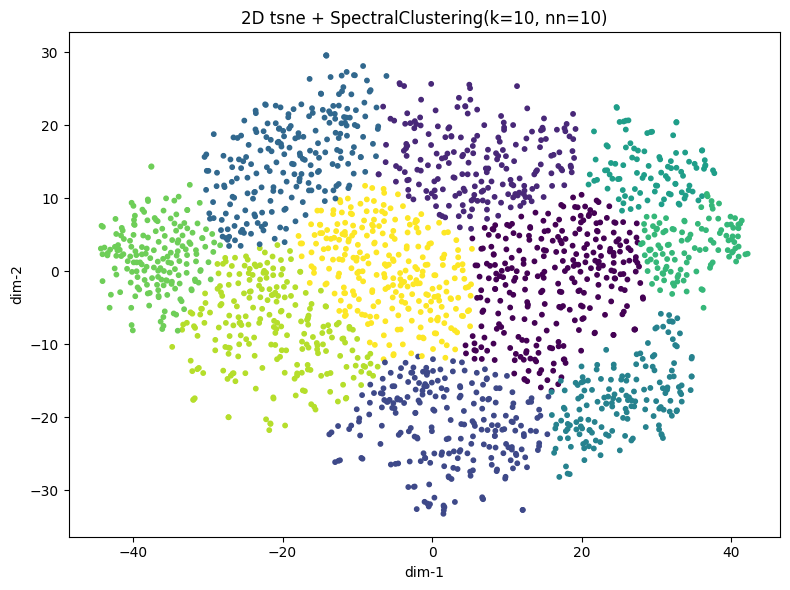

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(Z2_best[:, 0], Z2_best[:, 1], c=clusters_best, s=10)
plt.title(f"2D {best_method} + SpectralClustering(k={best_k}, nn={best_nn})")
plt.xlabel("dim-1")
plt.ylabel("dim-2")
plt.tight_layout()
plt.show()


## Συγκριση με true labels

Εδω δεν “εκπαιδευω” κατι με labels. Απλα βλεπω αν οπτικα τα clusters εχουν καποια αντιστοιχια με τις κλασεις του CIFAR-10.


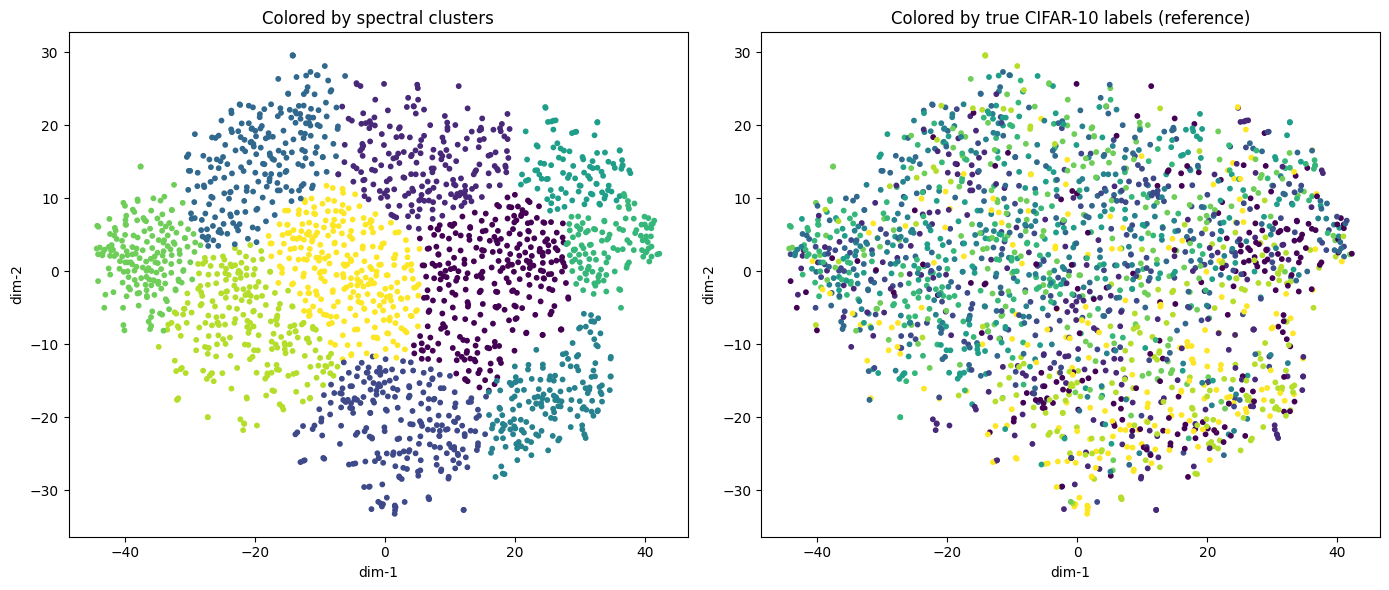

In [16]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(Z2_best[:, 0], Z2_best[:, 1], c=clusters_best, s=10)
plt.title("Colored by spectral clusters")
plt.xlabel("dim-1"); plt.ylabel("dim-2")

plt.subplot(1, 2, 2)
plt.scatter(Z2_best[:, 0], Z2_best[:, 1], c=y_train_sub, s=10)
plt.title("Colored by true CIFAR-10 labels (reference)")
plt.xlabel("dim-1"); plt.ylabel("dim-2")

plt.tight_layout()
plt.show()


## Top-3 αποτελεσματα για report

Εμφανιζω τα καλυτερα 3 runs, ωστε να τεκμηριωσω στην αναφορα οτι εκανα εξερευνηση διαφορετικων συνδιασμων (μεθοδοι + παραμετροι).


In [17]:
# top-3 με βαση NMI
topN = sorted(results, key=lambda d: d["NMI"], reverse=True)[:3]
for i, r in enumerate(topN, 1):
    print(i, r)


1 {'method': 'tsne', 'n_neighbors': 10, 'tsne_perplexity': 20, 'n_clusters': 10, 'embed_time_sec': 4.741849145037122, 'cluster_time_sec': 0.42309907090384513, 'ARI': 0.03984839347910291, 'NMI': np.float64(0.09400487804110631)}
2 {'method': 'tsne', 'n_neighbors': 15, 'tsne_perplexity': 20, 'n_clusters': 10, 'embed_time_sec': 4.76508238108363, 'cluster_time_sec': 0.4941082949517295, 'ARI': 0.03972213486140363, 'NMI': np.float64(0.09246212107020249)}
3 {'method': 'tsne', 'n_neighbors': 30, 'tsne_perplexity': 20, 'n_clusters': 10, 'embed_time_sec': 3.529519726987928, 'cluster_time_sec': 0.3782520409440622, 'ARI': 0.03615861707615505, 'NMI': np.float64(0.0894571259841414)}


Σε raw pixels, οι αποστασεις δεν αποτυπωνουν καλα την “σημασιολογικη” ομοιοτητα, αρα τα clusters δεν ευθυγραμμιζονται με τις κλασεις.

Παρ’ ολα αυτα, το notebook υλοποιει ακριβως αυτο που ζηταει η εκφωνηση: 2D embedding (graph/similarity) -> spectral clustering -> visualization, και επιπλεον κανει exploration συνδιασμων.